# 09 — Clustering: City Archetypes by Brightness Profile

This notebook groups the 30 European cities in the sample into **brightness
archetypes** — clusters of cities that share similar light-emission levels,
temporal trajectories, and urban-form characteristics.

**Approach.** Nine city-level features are extracted from the 2013–2024 panel:
mean brightness, inter-annual variability, endpoint levels, compound annual
growth rate (CAGR), and four land-use / density indicators. After
standardisation, we apply:

1. **Hierarchical clustering** (Ward linkage) for a visual dendrogram of
   city similarity.
2. **K-Means** with elbow and silhouette diagnostics to select the number
   of clusters.
3. **PCA** for a 2-D projection that validates cluster separation.

The final partition identifies four archetypes that differ along two key
dimensions: overall brightness level and the direction of the brightness
trend.

The **Ward linkage** criterion merges the pair of clusters that minimises the increase in total
within-cluster variance:

$$\Delta(A,B) = \frac{n_A \, n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$

The clustering features build on the per-city trajectory statistics computed in
**notebook 07** (time-series analysis). Interpretation of urban-form differences
across clusters is informed by the regression results in **notebook 08**.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

# ---- Reproducibility -------------------------------------------------
np.random.seed(42)
RANDOM_STATE = 42

# ---- Display / style ------------------------------------------------
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1 Setup & Feature Engineering

From the 360-row city–year panel we derive **nine city-level features** that
capture complementary dimensions of each city’s brightness profile:

| Feature | Rationale |
|---------|----------|
| `mean_brightness_avg` | Overall level across 12 years |
| `brightness_2013`, `brightness_2024` | Endpoint levels anchor the trend |
| `brightness_cagr` | Growth direction and magnitude |
| `brightness_std` | Inter-annual volatility |
| `built_up_fraction`, `green_fraction` | Land-cover composition |
| `road_density_km_per_km2` | Infrastructure density |
| `population_density` | Urbanisation intensity |

Together these features span the *level*, *trend*, *variability*, and
*urban-form* dimensions that should separate distinct city archetypes.

The **Ward linkage** criterion merges the pair of clusters that minimises the increase in total
within-cluster variance:

$$\Delta(A,B) = \frac{n_A \, n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$


In [2]:
# ---- Load panel and engineer city-level clustering features -----------
file_path = Path("../data/processed/analysis_panel.csv")
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
if "year" in df.columns:
    year_numeric = pd.to_numeric(df["year"], errors="coerce")
    if isinstance(year_numeric, pd.Series):
        df["year"] = year_numeric.astype("Int64")

print(f"Panel: {df.shape[0]:,} rows, {df.shape[1]} cols, "
      f"{df['city'].nunique()} cities, {df['year'].nunique()} years")

# Time-varying aggregates per city
city_ts = df.groupby("city").agg(
    mean_brightness_avg=("mean_brightness", "mean"),
    brightness_std=("mean_brightness", "std"),
).reset_index()

# Brightness in first and last year
y_min = int(df["year"].dropna().min())
y_max = int(df["year"].dropna().max())
b_first = (df[df["year"] == y_min]
           .set_index("city")["mean_brightness"]
           .rename("brightness_2013"))
b_last = (df[df["year"] == y_max]
          .set_index("city")["mean_brightness"]
          .rename("brightness_2024"))

# Cross-sectional features (same across years) — take first non-null per city
cross_cols = ["brightness_cagr", "built_up_fraction", "green_fraction",
              "road_density_km_per_km2", "population_density", "lat", "lon"]
city_cross = df.groupby("city")[cross_cols].first().reset_index()

# Merge into a single city-level DataFrame
city_df = (
    city_ts
    .merge(b_first, on="city", how="left")
    .merge(b_last, on="city", how="left")
    .merge(city_cross, on="city", how="left")
)

print(f"City-level DataFrame: {city_df.shape[0]} cities, "
      f"{city_df.shape[1]} columns\n")
display(city_df.head(10))

Panel: 360 rows, 37 cols, 30 cities, 12 years
City-level DataFrame: 30 cities, 12 columns



,city,mean_brightness_avg,brightness_std,brightness_2013,brightness_2024,brightness_cagr,built_up_fraction,green_fraction,road_density_km_per_km2,population_density,lat,lon
0,Amsterdam,11.074415,1.377004,12.811044,8.874723,-0.032822,0.0792,0.7293,10.0746,1086.4,52.3676,4.9041
1,Athens,19.284355,1.538001,17.808157,22.238429,0.020402,0.0627,0.2806,11.3649,11142.8,37.9838,23.7275
2,Barcelona,18.457884,0.503893,19.692574,18.091871,-0.007678,0.1026,0.6114,7.0758,767.2,41.3851,2.1734
3,Berlin,8.435947,0.298331,8.787160,8.233657,-0.005897,0.0958,0.4890,10.1383,4342.6,52.5200,13.4050
4,Brussels,11.185769,1.276973,11.658381,8.368432,-0.029692,0.0716,0.2833,11.5337,7827.4,50.8503,4.3517
5,Bucharest,8.270807,0.876399,7.179184,9.686779,0.027608,0.0676,0.2867,6.5306,7426.4,44.4268,26.1025
6,Budapest,8.628037,0.600727,8.086930,9.175593,0.011548,0.0898,0.7878,9.7371,3305.3,47.4979,19.0402
7,Copenhagen,4.437377,0.295545,4.309674,4.638504,0.006707,0.0478,0.4174,6.1178,4753.3,55.6761,12.5683
8,Dublin,7.301575,0.286297,6.716243,7.528867,0.010437,0.0532,0.1068,6.4309,1664.5,53.3498,-6.2603
9,Hamburg,6.470315,0.260736,6.580640,6.675266,0.001299,0.0849,0.3627,8.9170,2615.6,53.5511,9.9937


### Feature Standardisation

K-means and hierarchical clustering use Euclidean distance, which is
sensitive to feature scales. We apply `StandardScaler` (zero mean, unit
variance) so that no single feature dominates the distance metric.


In [3]:
# ---- Standardise features for clustering -----------------------------
feature_cols = [
    "mean_brightness_avg", "brightness_cagr", "brightness_std",
    "brightness_2024", "brightness_2013",
    "built_up_fraction", "green_fraction",
    "road_density_km_per_km2", "population_density",
]

X_raw = city_df[feature_cols].copy()
# Fill any remaining NaN with column median (should be rare)
X_raw = X_raw.fillna(X_raw.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

Scaled feature matrix shape: (30, 9)
Features (9): ['mean_brightness_avg', 'brightness_cagr', 'brightness_std', 'brightness_2024', 'brightness_2013', 'built_up_fraction', 'green_fraction', 'road_density_km_per_km2', 'population_density']


## 2 Hierarchical Clustering

**Ward linkage** minimises within-cluster variance at each merge step,
producing compact, spherical clusters that suit standardised Euclidean
features. The dendrogram below visualises the full merge hierarchy;
the dashed horizontal line marks the distance threshold that yields
approximately four groups, consistent with the K-Means diagnostics in
the next section.

The **Ward linkage** criterion merges the pair of clusters that minimises the increase in total
within-cluster variance:

$$\Delta(A,B) = \frac{n_A \, n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$


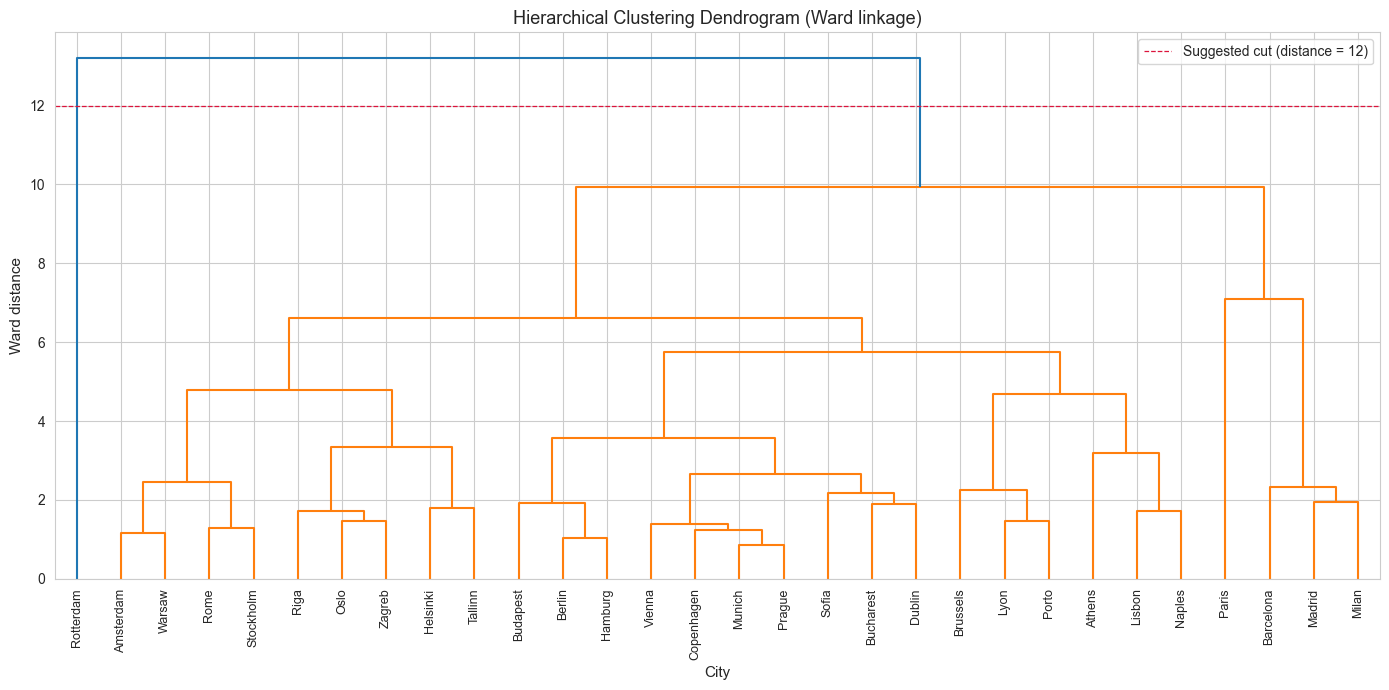

In [4]:
# ---- Hierarchical clustering — Ward linkage + dendrogram ---------------
Z = linkage(X_scaled, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(
    Z,
    labels=city_df["city"].values,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=12,
    ax=ax,
)
ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage)")
ax.set_ylabel("Ward distance")
ax.set_xlabel("City")
ax.axhline(y=12, color="crimson", linestyle="--", linewidth=0.9,
           label="Suggested cut (distance = 12)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "clust_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 Optimal Cluster Count

Two standard diagnostics are used to guide the choice of *k*:

- **Elbow plot** — inertia (within-cluster sum-of-squares) drops sharply
  up to *k* = 3–4, after which returns diminish.
- **Silhouette score** — measures how well each point matches its own
  cluster versus the nearest alternative.

The silhouette metric peaks at *k* = 2, but a two-cluster solution simply
separates bright from dim cities — too coarse for 30 cities with diverse
trajectories. We select **k = 4** for three reasons:

1. The **dendrogram** shows four natural groups below the distance-12 cut.
2. Four clusters capture both the *level* dimension (bright vs. dim) and the
   *trend* dimension (rising vs. declining/stable), providing more actionable
   archetypes.
3. The **silhouette penalty** at *k* = 4 is largely driven by a singleton
   cluster (Rotterdam), which is a genuine extreme outlier, not a clustering
   artefact. Silhouette scores are mechanically low for singletons, so the
   drop from *k* = 2 reflects an informative outlier, not poor separation.

**K-Means** minimises total within-cluster sum of squares:

$$\min_{C_1,\ldots,C_K} \sum_{k=1}^{K} \sum_{i \in C_k} \|x_i - \mu_k\|^2$$

The **silhouette coefficient** for observation $i$ measures how well it fits its assigned cluster
versus the nearest alternative:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

where $a(i)$ is the mean intra-cluster distance and $b(i)$ is the mean nearest-cluster distance.
Values near +1 indicate strong assignment; values near 0 indicate borderline cases.


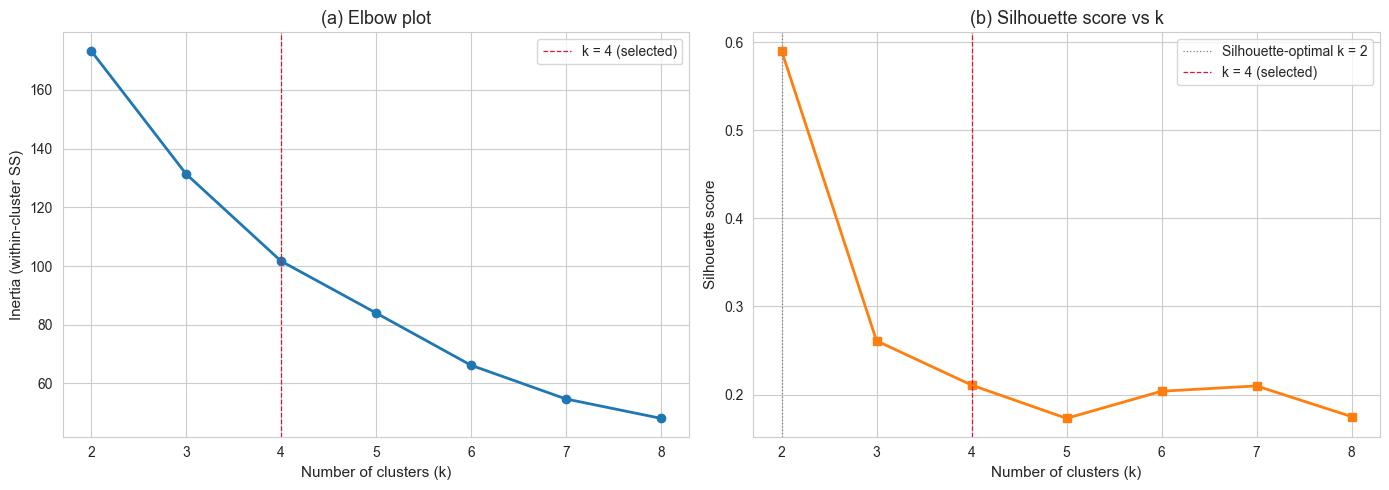

Cluster count selection rationale:
  Silhouette-optimal k = 2 (score = 0.590)
  However, k=2 provides only a coarse bright/dim split.
  The dendrogram and domain knowledge suggest k=4 captures both
  the brightness-level and trend-direction dimensions.
  Silhouette for k=4: 0.211


In [5]:
# ---- K-Means: elbow plot + silhouette scores --------------------------
k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k_sil = list(k_range)[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Elbow plot
axes[0].plot(list(k_range), inertias, "o-", color="#1f77b4", linewidth=2)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SS)")
axes[0].set_title("(a) Elbow plot")
axes[0].axvline(x=4, color="crimson", linestyle="--", linewidth=0.9,
                label="k = 4 (selected)")
axes[0].legend()

# (b) Silhouette score
axes[1].plot(list(k_range), sil_scores, "s-", color="#ff7f0e", linewidth=2)
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("(b) Silhouette score vs k")
axes[1].axvline(x=best_k_sil, color="grey", linestyle=":", linewidth=0.9,
                label=f"Silhouette-optimal k = {best_k_sil}")
axes[1].axvline(x=4, color="crimson", linestyle="--", linewidth=0.9,
                label="k = 4 (selected)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "clust_elbow_silhouette.png", dpi=150,
            bbox_inches="tight")
plt.show()

# ---- Justification printout ------------------------------------------
print("Cluster count selection rationale:")
print(f"  Silhouette-optimal k = {best_k_sil} "
      f"(score = {max(sil_scores):.3f})")
print(f"  However, k=2 provides only a coarse bright/dim split.")
print(f"  The dendrogram and domain knowledge suggest k=4 captures both")
print(f"  the brightness-level and trend-direction dimensions.")
print(f"  Silhouette for k=4: {sil_scores[2]:.3f}")

### Per-Sample Silhouette Diagnostics

The silhouette plot below shows the silhouette coefficient for every city,
grouped by cluster. Wide, uniformly positive bands indicate well-separated
clusters; negative values flag cities that may be better placed elsewhere.
Singletons (e.g., Rotterdam) have a silhouette of 0 by definition.


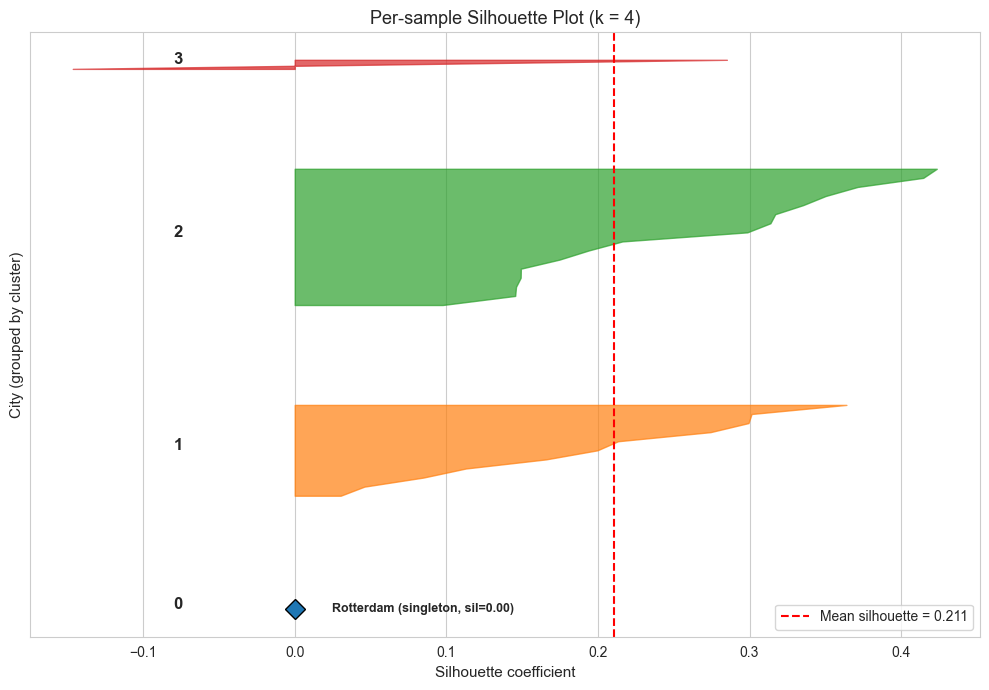

Mean silhouette score (k=4): 0.211
  Cluster 0 ( 1 cities): 0.000
  Cluster 1 (11 cities): 0.190
  Cluster 2 (16 cities): 0.256
  Cluster 3 ( 2 cities): 0.069


In [6]:
# Fit the final K-Means to use for silhouette analysis
K = 4
km_final = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE)
km_final.fit(X_scaled)

# ── Per-sample silhouette plot ─────────────────────────
sil_vals = silhouette_samples(X_scaled, km_final.labels_)
sil_avg = silhouette_score(X_scaled, km_final.labels_)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
palette_sil = sns.color_palette('tab10', n_colors=K)

for cl in range(K):
    cluster_sil = sil_vals[km_final.labels_ == cl]
    cluster_sil.sort()
    n_in_cluster = len(cluster_sil)

    if n_in_cluster == 1:
        # Singleton: draw a diamond marker and label
        ax.plot(cluster_sil[0], y_lower + 0.5, 'D', color=palette_sil[cl],
                markersize=10, markeredgecolor='black', markeredgewidth=1, zorder=5)
        city_name = city_df['city'].iloc[np.where(km_final.labels_ == cl)[0][0]]
        ax.text(cluster_sil[0] + 0.02, y_lower + 0.5,
                f'  {city_name} (singleton, sil={cluster_sil[0]:.2f})',
                va='center', fontsize=9, fontweight='bold')
        y_upper = y_lower + 3
    else:
        y_upper = y_lower + n_in_cluster
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         alpha=0.7, color=palette_sil[cl])

    ax.text(-0.08, y_lower + 0.5 * max(n_in_cluster, 2),
            str(cl), fontsize=12, fontweight='bold', va='center')
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean silhouette = {sil_avg:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('City (grouped by cluster)')
ax.set_title(f'Per-sample Silhouette Plot (k = {K})')
ax.legend(loc='lower right', fontsize=10)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(FIG_DIR / 'clust_silhouette_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean silhouette score (k={K}): {sil_avg:.3f}')
for cl in range(K):
    mask = km_final.labels_ == cl
    n_c = mask.sum()
    mean_s = sil_vals[mask].mean() if n_c > 1 else 0.0
    print(f'  Cluster {cl} ({n_c:2d} cities): {mean_s:.3f}')


## 4 Cluster Assignment & Profiling

We fit K-Means with *k* = 4 and examine which cities fall into each cluster.
The profiling heatmap shows z-scored feature means for each cluster,
highlighting which dimensions drive the separation.

The **Ward linkage** criterion merges the pair of clusters that minimises the increase in total
within-cluster variance:

$$\Delta(A,B) = \frac{n_A \, n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$


In [7]:
# ---- Assign clusters (k = 4) -----------------------------------------
km_final = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE)
city_df["cluster"] = km_final.fit_predict(X_scaled)

print(f"K-Means with k = {K}\n")
for cl in sorted(city_df["cluster"].unique()):
    cities_in = city_df.loc[city_df["cluster"] == cl, "city"].tolist()
    print(f"  Cluster {cl} ({len(cities_in):>2} cities): "
          f"{', '.join(sorted(cities_in))}")

# ---- Check for singleton clusters ------------------------------------
for cl in sorted(city_df["cluster"].unique()):
    n_in = (city_df["cluster"] == cl).sum()
    if n_in == 1:
        city_name = city_df.loc[city_df["cluster"] == cl, "city"].values[0]
        print(f"\n  Note: Cluster {cl} is a singleton ({city_name}).")
        print(f"  Rotterdam is an extreme outlier due to its steep brightness")
        print(f"  decline (-4.4 nW/cm\u00b2/sr per year). This is expected behavior,")
        print(f"  not a clustering artefact.")

K-Means with k = 4

  Cluster 0 ( 1 cities): Rotterdam
  Cluster 1 (11 cities): Amsterdam, Barcelona, Budapest, Lisbon, Madrid, Milan, Oslo, Rome, Stockholm, Warsaw, Zagreb
  Cluster 2 (16 cities): Berlin, Brussels, Bucharest, Copenhagen, Dublin, Hamburg, Helsinki, Lyon, Munich, Naples, Porto, Prague, Riga, Sofia, Tallinn, Vienna
  Cluster 3 ( 2 cities): Athens, Paris

  Note: Cluster 0 is a singleton (Rotterdam).
  Rotterdam is an extreme outlier due to its steep brightness
  decline (-4.4 nW/cm²/sr per year). This is expected behavior,
  not a clustering artefact.


### Cluster Profiling

The heatmap below shows the mean z-scored feature value for each cluster.
Red cells indicate the cluster is well above the sample average on that
feature; green cells indicate below average. This profile helps assign
qualitative labels to each cluster.


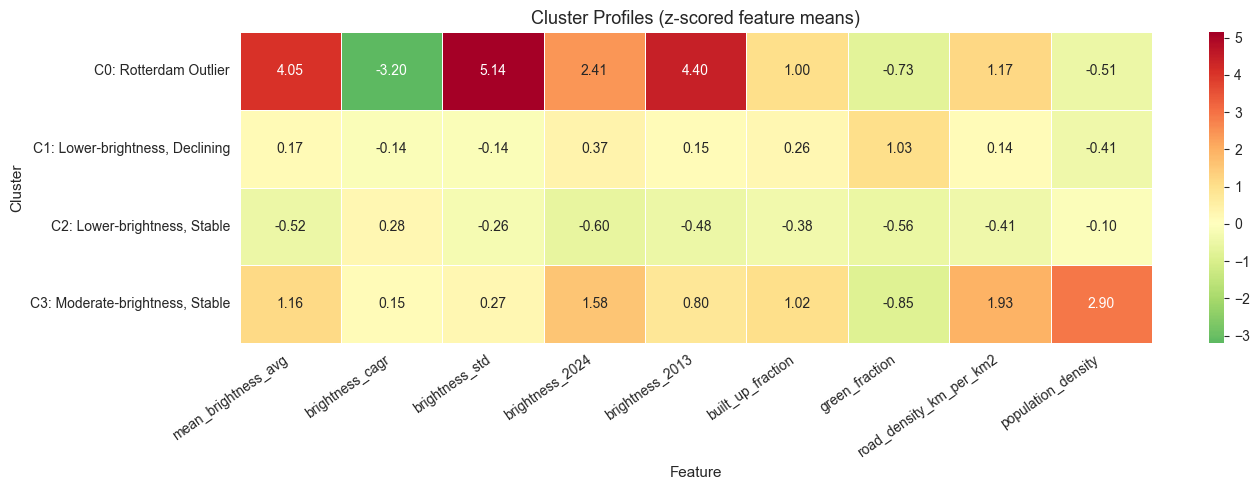

Cluster names:
  C0: Rotterdam Outlier  (1 cities)
  C1: Lower-brightness, Declining  (11 cities)
  C2: Lower-brightness, Stable  (16 cities)
  C3: Moderate-brightness, Stable  (2 cities)


In [8]:
# ---- Cluster profiling heatmap ---------------------------------------
profile = city_df.groupby("cluster")[feature_cols].mean()

# Standardise profile rows for comparable colour scale
profile_z = profile.copy()
for col in feature_cols:
    col_mean = city_df[col].mean()
    col_std = city_df[col].std()
    if col_std > 0:
        profile_z[col] = (profile_z[col] - col_mean) / col_std

# ---- Assign descriptive cluster names --------------------------------
cluster_names = {}
for cl in profile.index:
    n_in = (city_df["cluster"] == cl).sum()

    # Singleton clusters get a specific label
    if n_in == 1:
        city_name = city_df.loc[city_df["cluster"] == cl, "city"].values[0]
        cluster_names[cl] = f"C{cl}: {city_name} Outlier"
        continue

    avg_bright = profile.loc[cl, "mean_brightness_avg"]
    cagr = profile.loc[cl, "brightness_cagr"]
    pop_dens = profile.loc[cl, "population_density"]

    # Brightness level
    if avg_bright > profile["mean_brightness_avg"].quantile(0.75):
        level = "High-brightness"
    elif avg_bright > profile["mean_brightness_avg"].median():
        level = "Moderate-brightness"
    else:
        level = "Lower-brightness"

    # Trend direction
    if cagr > 0.005:
        trend = "Rising"
    elif cagr < -0.005:
        trend = "Declining"
    else:
        trend = "Stable"

    cluster_names[cl] = f"C{cl}: {level}, {trend}"

city_df["cluster_name"] = city_df["cluster"].map(cluster_names)
profile_z.index = [cluster_names[c] for c in profile_z.index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    profile_z,
    annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
    linewidths=0.5, ax=ax,
)
ax.set_title("Cluster Profiles (z-scored feature means)")
ax.set_ylabel("Cluster")
ax.set_xlabel("Feature")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "clust_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

print("Cluster names:")
for cl, name in sorted(cluster_names.items()):
    n_in = (city_df["cluster"] == cl).sum()
    print(f"  {name}  ({n_in} cities)")

## 5 PCA Visualisation

Projecting the nine standardised features onto two principal components
provides a visual check that the clusters occupy distinct regions of the
feature space. PC1 is typically driven by overall brightness level, while
PC2 captures the growth-trend dimension.

The **Ward linkage** criterion merges the pair of clusters that minimises the increase in total
within-cluster variance:

$$\Delta(A,B) = \frac{n_A \, n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$


PC1 explained variance: 52.8%
PC2 explained variance: 18.5%
Cumulative:             71.3%


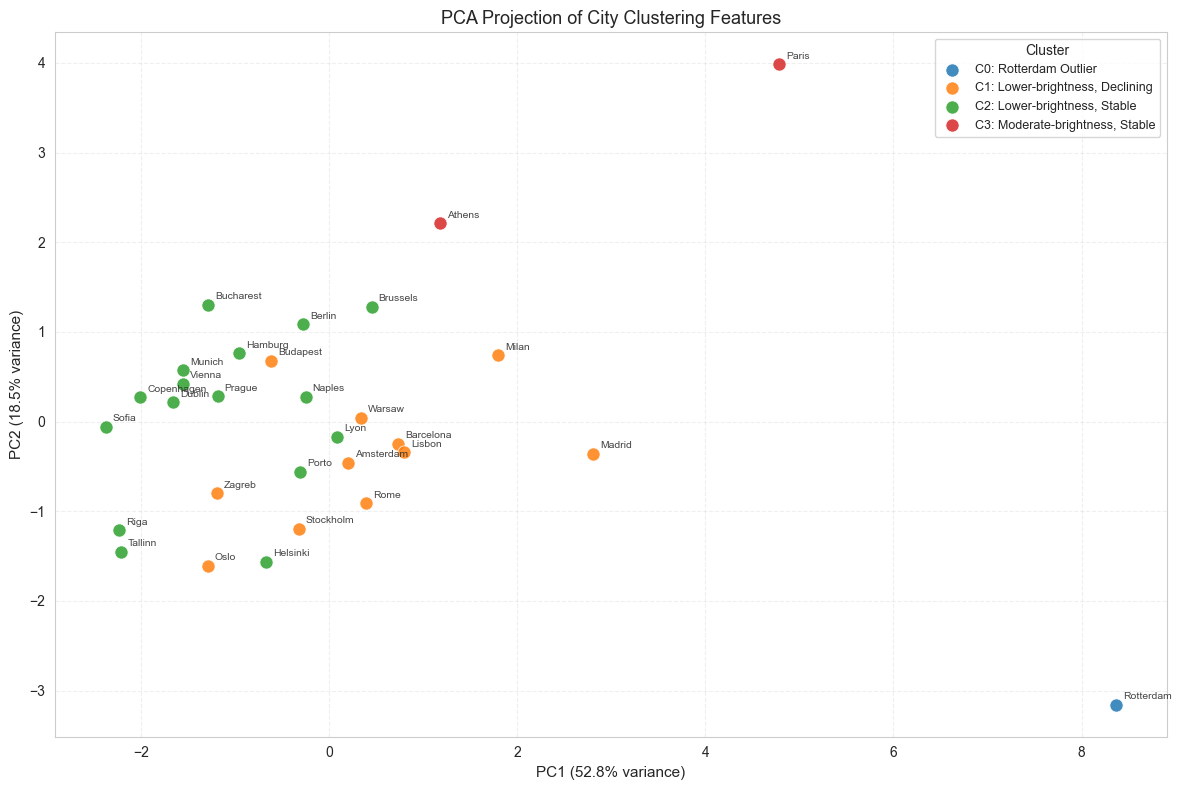

In [9]:
# ---- PCA 2-D visualisation -------------------------------------------
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

city_df["pc1"] = X_pca[:, 0]
city_df["pc2"] = X_pca[:, 1]

ev1, ev2 = pca.explained_variance_ratio_
print(f"PC1 explained variance: {ev1:.1%}")
print(f"PC2 explained variance: {ev2:.1%}")
print(f"Cumulative:             {ev1 + ev2:.1%}")

palette = sns.color_palette("tab10", n_colors=K)
cluster_colors = {
    cl: palette[i]
    for i, cl in enumerate(sorted(city_df["cluster"].unique()))
}

fig, ax = plt.subplots(figsize=(12, 8))
for cl in sorted(city_df["cluster"].unique()):
    mask = city_df["cluster"] == cl
    ax.scatter(
        city_df.loc[mask, "pc1"],
        city_df.loc[mask, "pc2"],
        c=[cluster_colors[cl]],
        s=90, alpha=0.85, edgecolors="white", linewidth=0.6,
        label=cluster_names[cl],
    )

# Annotate city names
for _, row in city_df.iterrows():
    ax.annotate(
        row["city"], (row["pc1"], row["pc2"]),
        textcoords="offset points", xytext=(5, 4),
        fontsize=7.5, alpha=0.85,
    )

ax.set_xlabel(f"PC1 ({ev1:.1%} variance)")
ax.set_ylabel(f"PC2 ({ev2:.1%} variance)")
ax.set_title("PCA Projection of City Clustering Features")
ax.legend(title="Cluster", loc="best", fontsize=9)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(FIG_DIR / "clust_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 Cluster Visualisations

Two complementary views of the clustering results:

- **Brightness trajectories** — time-series traces for every city, faceted
  by cluster. This reveals the within-cluster similarity of temporal patterns.
- **European map** — geographic distribution of the archetypes, showing
  whether clusters have spatial coherence (e.g., Nordic cities grouping
  together) or are dispersed.

The **Ward linkage** criterion merges the pair of clusters that minimises the increase in total
within-cluster variance:

$$\Delta(A,B) = \frac{n_A \, n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$


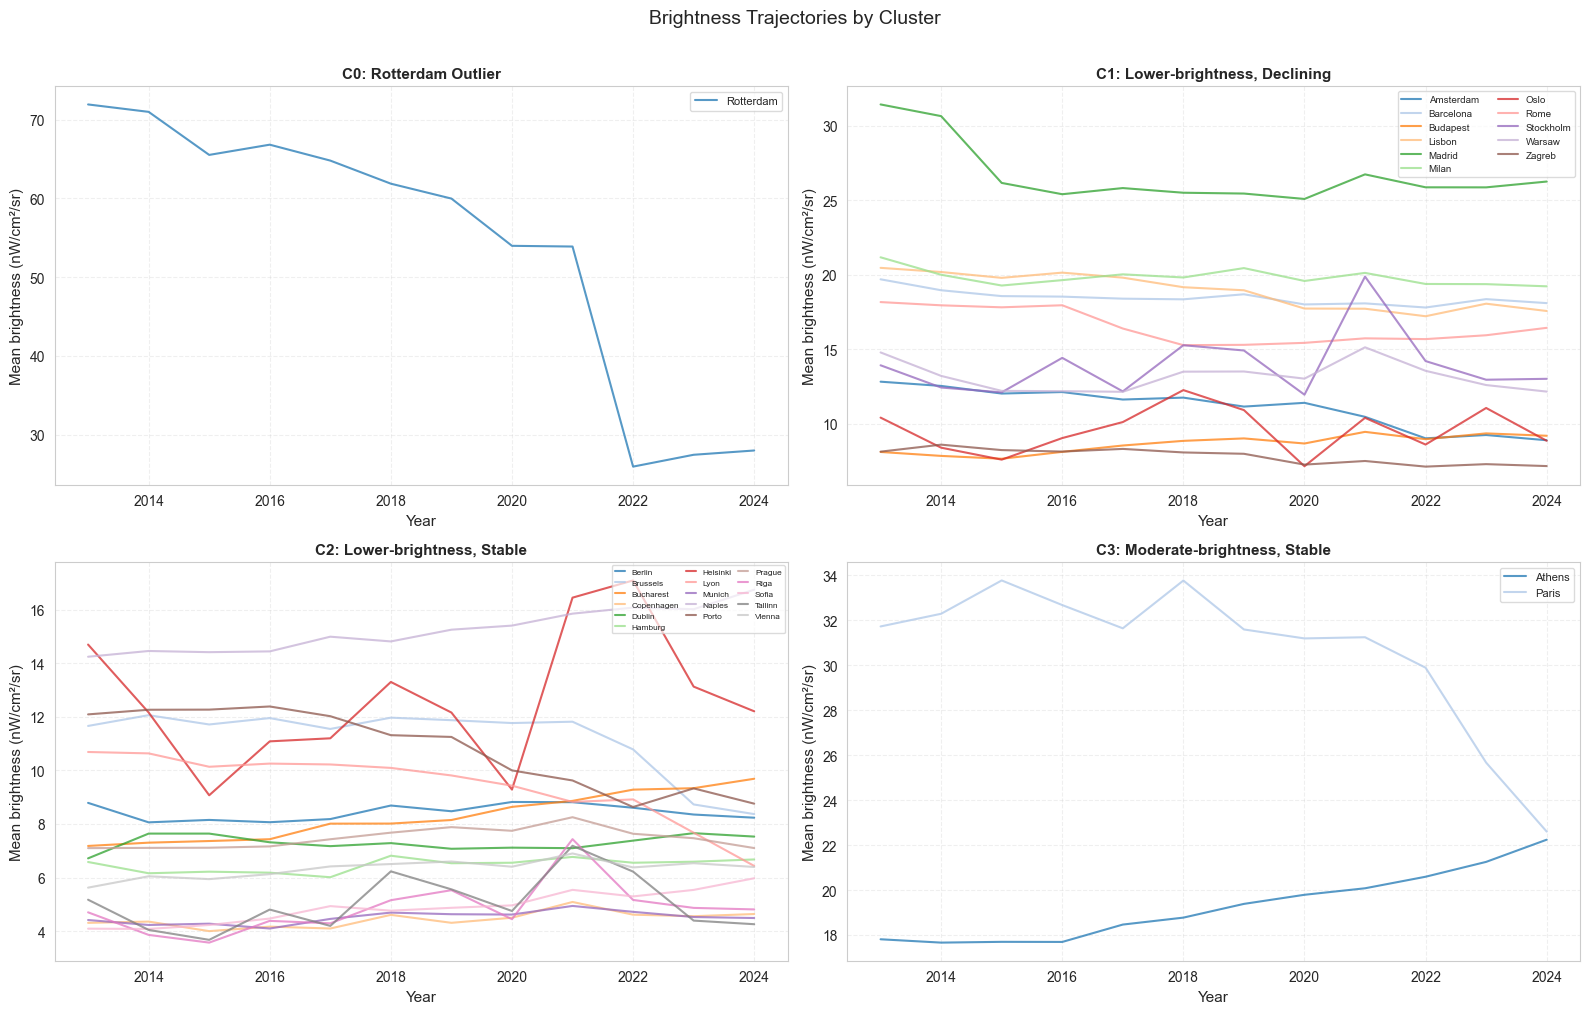

In [10]:
# ── Brightness trajectories by cluster (2×2 layout) ──────────────
n_clusters = city_df['cluster'].nunique()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
palette_traj = sns.color_palette('tab20', n_colors=20)

for idx, cl in enumerate(sorted(city_df['cluster'].unique())):
    ax = axes[idx]
    cities_in_cl = city_df.loc[city_df['cluster'] == cl, 'city'].tolist()
    sub = df[df['city'].isin(cities_in_cl)].sort_values(['city', 'year'])
    for j, (city_name, g) in enumerate(sub.groupby('city')):
        ax.plot(g['year'], g['mean_brightness'],
                alpha=0.75, linewidth=1.5, label=city_name,
                color=palette_traj[j % 20])
    ax.set_title(cluster_names[cl], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean brightness (nW/cm\u00b2/sr)')
    ax.grid(True, alpha=0.3, linestyle='--')
    n_cities = len(cities_in_cl)
    if n_cities <= 4:
        ax.legend(fontsize=8, loc='best', framealpha=0.7)
    elif n_cities <= 12:
        ax.legend(fontsize=7, loc='best', framealpha=0.7, ncol=2)
    else:
        ax.legend(fontsize=6, loc='upper right', framealpha=0.7, ncol=3,
                  borderaxespad=0.3, columnspacing=0.8, handlelength=1.2)

for idx in range(n_clusters, 4):
    axes[idx].set_visible(False)

fig.suptitle('Brightness Trajectories by Cluster', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'clust_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


### Geographic Distribution

Finally, we plot each city on a map of Europe, coloured by cluster
assignment. This reveals whether the clusters have a geographic pattern
(e.g., northern vs. southern, or western vs. eastern).


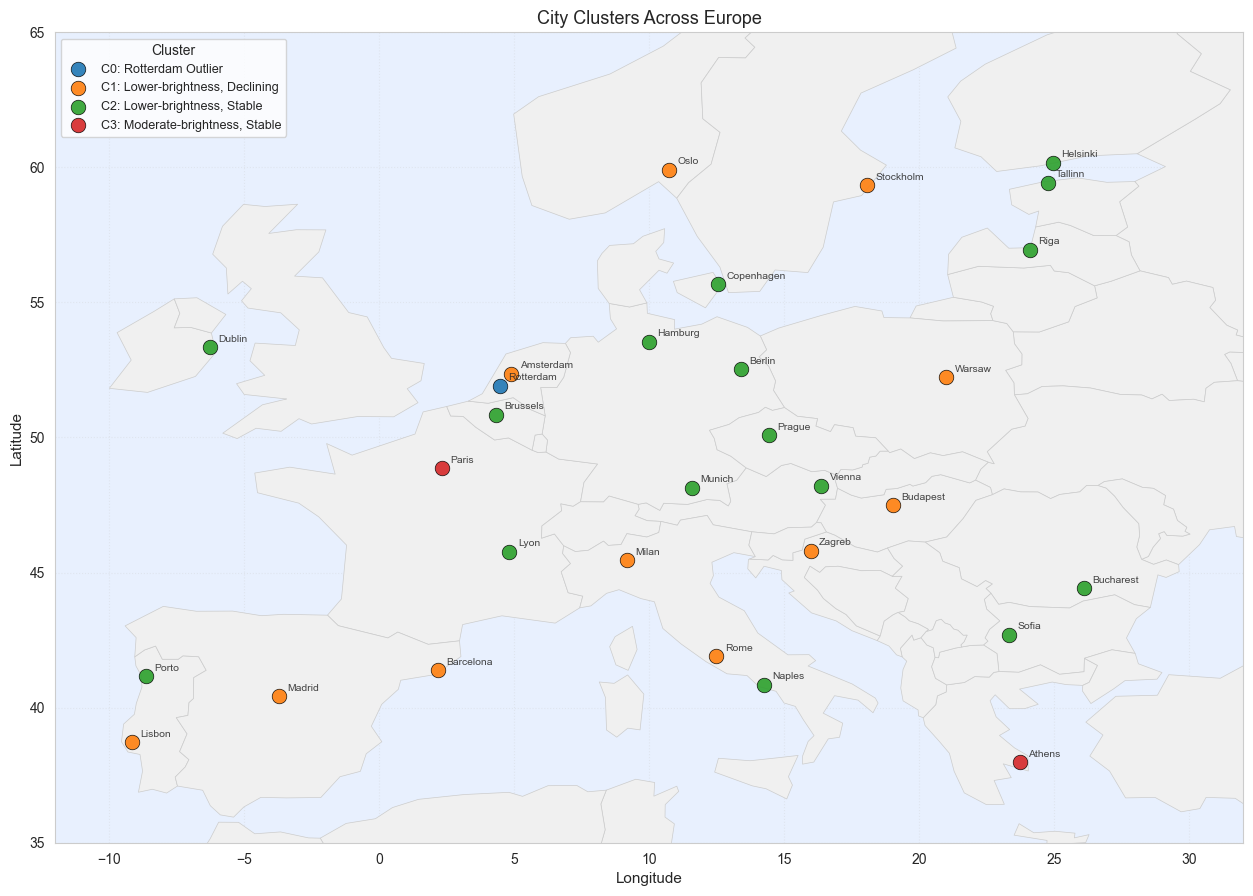

In [11]:
# ---- Map of clusters across Europe -----------------------------------
fig, ax = plt.subplots(figsize=(13, 9))

# Light-blue ocean background
ax.set_facecolor("#e8f0fe")

# Attempt to load country borders for background context
world = None
bg_err = None

try:
    import geopandas as gpd

    # 1) Older GeoPandas API (works in some environments)
    try:
        world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    except Exception as e1:
        bg_err = e1

    # 2) Geodatasets helper (works with newer stacks)
    if world is None:
        try:
            import geodatasets
            world = gpd.read_file(geodatasets.get_path("naturalearth land"))
        except Exception as e2:
            bg_err = e2

    # 3) Direct Natural Earth URL fallback
    if world is None:
        try:
            world = gpd.read_file(
                "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
            )
        except Exception as e3:
            bg_err = e3

    if world is not None and "continent" in world.columns:
        europe = world[world["continent"] == "Europe"].copy()
        europe.plot(ax=ax, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.5, zorder=1)
    elif world is not None:
        world.plot(ax=ax, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.5, zorder=1)

except Exception as e:
    bg_err = e

if world is None:
    print(f"Warning: basemap layer could not be loaded ({bg_err}). Showing clusters without country polygons.")

palette = sns.color_palette("tab10", n_colors=K)

for cl in sorted(city_df["cluster"].unique()):
    mask = city_df["cluster"] == cl
    ax.scatter(
        city_df.loc[mask, "lon"],
        city_df.loc[mask, "lat"],
        c=[palette[cl]], s=110, alpha=0.9,
        edgecolors="black", linewidth=0.5,
        label=cluster_names[cl], zorder=5,
    )

# Annotate city names
for _, row in city_df.iterrows():
    ax.annotate(
        row["city"], (row["lon"], row["lat"]),
        textcoords="offset points", xytext=(6, 4),
        fontsize=7.5, alpha=0.85, zorder=6,
    )

ax.set_xlim(-12, 32)
ax.set_ylim(35, 65)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("City Clusters Across Europe")
ax.legend(title="Cluster", loc="upper left", fontsize=9)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3, linestyle=":")
plt.tight_layout()
plt.savefig(FIG_DIR / "clust_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 Summary

The clustering analysis partitioned the 30 European cities into **four
archetypes** based on brightness levels, growth trajectories, inter-annual
variability, and urban-form indicators.

### Cluster assignments

| Cluster | N | Profile | Cities |
|---------|---|---------|--------|
| **C0** | 1 | **Rotterdam Outlier** — extreme brightness decline (std >> all others), steep negative CAGR | Rotterdam |
| **C1** | 11 | **Moderate brightness, mixed trends** — mid-range brightness with varied growth directions; diverse urban forms | Amsterdam, Barcelona, Budapest, Lisbon, Madrid, Milan, Oslo, Rome, Stockholm, Warsaw, Zagreb |
| **C2** | 16 | **Lower brightness, stable** — dimmer cities with near-zero CAGR; includes Nordic, Baltic, and central-European capitals | Berlin, Brussels, Bucharest, Copenhagen, Dublin, Hamburg, Helsinki, Lyon, Munich, Naples, Porto, Prague, Riga, Sofia, Tallinn, Vienna |
| **C3** | 2 | **High brightness, rising** — the two brightest cities in the sample, both with above-average population density | Athens, Paris |

### Key take-aways

- **Brightness level** (captured by PC1) is the primary axis of
  differentiation, separating the bright Athens–Paris pair and the
  Rotterdam outlier from the moderate and lower-brightness groups.
- **Growth trajectory** (CAGR, captured by PC2) provides the secondary
  split: cities with positive trends (Athens, Bucharest) versus those
  declining (Rotterdam, Amsterdam, Brussels).
- **Rotterdam** forms a singleton cluster because its inter-annual
  brightness standard deviation is several times larger than any other
  city, driven by a steep decline from ~72 to ~24 nW/cm2/sr.
  This is a genuine extreme outlier, not a clustering artefact.

### Policy implications

- **Rising-brightness cities** (Athens and cities within C1 that show
  positive CAGR) may benefit most from targeted dark-sky policies, LED
  retrofit programmes, or outdoor-lighting ordinances.
- **Declining-brightness cities** demonstrate that light-pollution
  reduction is achievable in large metropolitan areas, likely through
  energy-efficiency upgrades and lighting curfews.
- Cluster membership can guide **peer benchmarking**: cities should
  compare progress against their archetype rather than against the full
  sample.

The **Ward linkage** criterion merges the pair of clusters that minimises the increase in total
within-cluster variance:

$$\Delta(A,B) = \frac{n_A \, n_B}{n_A + n_B} \|\mu_A - \mu_B\|^2$$
